# Ripeness Cross-Generalisation Test

Tests the three trained models on a separate fruit dataset containing **known fruits** (apple, banana, orange — seen during training) and **unknown fruits** (mango, tomato — never seen during training) to measure transfer learning and cross-generalisation ability.

**Key fix vs original:** Each model now uses its correct `preprocess_input` function instead of a shared `rescale=1./255`, which was the primary cause of the low EfficientNet and ResNet scores.

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import mobilenet_v2, efficientnet, resnet50
from sklearn.metrics import classification_report, confusion_matrix


2026-05-30 07:14:03.582391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780125243.877027      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780125243.962354      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780125244.717169      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780125244.717216      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780125244.717219      58 computation_placer.cc:177] computation placer alr

# Load Saved Models

In [3]:
model1 = load_model("/kaggle/input/notebooks/ritika156/modelling/mobilenet_model.h5")
model2 = load_model("/kaggle/input/notebooks/ritika156/modelling/efficientnet_model.h5")
model3 = load_model("/kaggle/input/notebooks/ritika156/modelling/resnet_model.h5")

print("All models loaded successfully.")


2026-05-30 07:14:22.373448: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


All models loaded successfully.


# Load Ensemble Weights

In [4]:
with open("/kaggle/input/notebooks/ritika156/modelling/ensemble_weights.json") as f:
    ew = json.load(f)

w1, w2, w3 = ew["w1"], ew["w2"], ew["w3"]
print(f"Ensemble weights — MobileNet: {w1:.3f} | EfficientNet: {w2:.3f} | ResNet: {w3:.3f}")


Ensemble weights — MobileNet: 0.332 | EfficientNet: 0.329 | ResNet: 0.339


# Model-to-Preprocessor Mapping

This is the core fix. Instead of one shared `rescale=1./255` generator, each model gets the preprocessing function it was pretrained with. This alone will substantially recover EfficientNet and ResNet accuracy.

In [5]:
# Each model must use the preprocessing it was designed for
MODEL_CONFIG = {
    "MobileNetV2":    {"model": model1, "preprocess": mobilenet_v2.preprocess_input},
    "EfficientNetB0": {"model": model2, "preprocess": efficientnet.preprocess_input},
    "ResNet50":       {"model": model3, "preprocess": resnet50.preprocess_input},
}


# Fruit Paths

In [6]:
fruit_paths = {
    # Known fruits — seen during training
    "Apple":  "/kaggle/input/datasets/ritika156/sortedfruits/sorted/known fruits/apple",
    "Banana": "/kaggle/input/datasets/ritika156/sortedfruits/sorted/known fruits/banana",
    "Orange": "/kaggle/input/datasets/ritika156/sortedfruits/sorted/known fruits/orange",

    # Unknown fruits — never seen during training (transfer learning test)
    "Mango":  "/kaggle/input/datasets/ritika156/sortedfruits/sorted/unknown fruit/mango",
    "Tomato": "/kaggle/input/datasets/ritika156/sortedfruits/sorted/unknown fruit/tomato",
}

KNOWN_FRUITS   = ["Apple", "Banana", "Orange"]
UNKNOWN_FRUITS = ["Mango", "Tomato"]


# Evaluation Function

In [7]:
def evaluate_fruit(model, preprocess_fn, fruit_path, fruit_name, model_name, save_cm=True):
    """
    Evaluates a single model on a single fruit's folder.
    Uses the model-specific preprocess_fn — NOT rescale=1./255.
    """

    datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    generator = datagen.flow_from_directory(
        fruit_path,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print(f"\n{'='*55}")
    print(f"  {model_name}  |  {fruit_name}")
    print(f"{'='*55}")

    results     = model.evaluate(generator, verbose=0)
    predictions = model.predict(generator, verbose=0)

    y_pred       = np.argmax(predictions, axis=1)
    y_true       = generator.classes
    class_names  = list(generator.class_indices.keys())

    print(f"  Accuracy : {results[1]:.4f}")
    print(f"  Loss     : {results[0]:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{model_name} — {fruit_name}")
        plt.ylabel("True")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.savefig(f"cm_{model_name}_{fruit_name}.png", dpi=120)
        plt.show()

    return results[1], predictions, y_true, generator.class_indices


# Run Evaluation — All Models × All Fruits

Found 771 images belonging to 3 classes.

  MobileNetV2  |  Apple
  Accuracy : 0.5551
  Loss     : 2.7315

Classification Report:
              precision    recall  f1-score   support

    overripe       0.49      0.79      0.61       133
        ripe       0.59      0.30      0.40       319
      unripe       0.57      0.71      0.64       319

    accuracy                           0.56       771
   macro avg       0.55      0.60      0.55       771
weighted avg       0.57      0.56      0.53       771



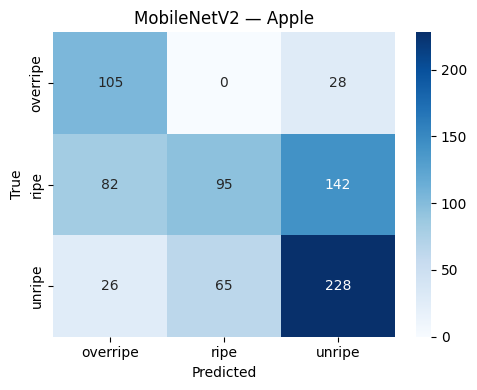

Found 1090 images belonging to 3 classes.

  MobileNetV2  |  Banana
  Accuracy : 0.6917
  Loss     : 1.1270

Classification Report:
              precision    recall  f1-score   support

    overripe       0.76      0.90      0.83       341
        ripe       0.53      0.85      0.65       291
      unripe       0.92      0.44      0.59       458

    accuracy                           0.69      1090
   macro avg       0.74      0.73      0.69      1090
weighted avg       0.76      0.69      0.68      1090



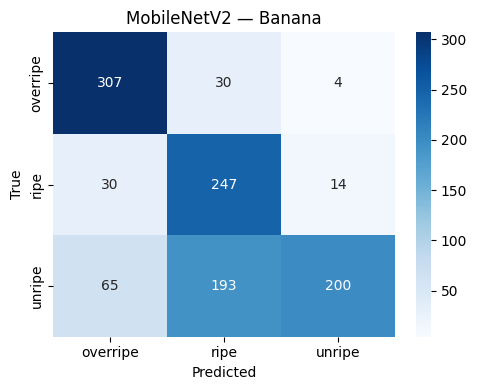

Found 328 images belonging to 3 classes.

  MobileNetV2  |  Orange
  Accuracy : 0.7073
  Loss     : 1.7801

Classification Report:
              precision    recall  f1-score   support

    overripe       0.85      0.71      0.77        86
        ripe       0.66      0.59      0.63       113
      unripe       0.67      0.81      0.73       129

    accuracy                           0.71       328
   macro avg       0.73      0.70      0.71       328
weighted avg       0.71      0.71      0.71       328



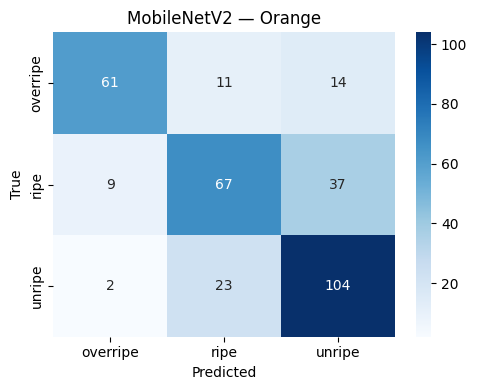

Found 1240 images belonging to 3 classes.

  MobileNetV2  |  Mango
  Accuracy : 0.4040
  Loss     : 2.8744

Classification Report:
              precision    recall  f1-score   support

    overripe       0.24      0.67      0.36       138
        ripe       0.46      0.37      0.41       510
      unripe       0.49      0.37      0.42       592

    accuracy                           0.40      1240
   macro avg       0.40      0.47      0.40      1240
weighted avg       0.45      0.40      0.41      1240



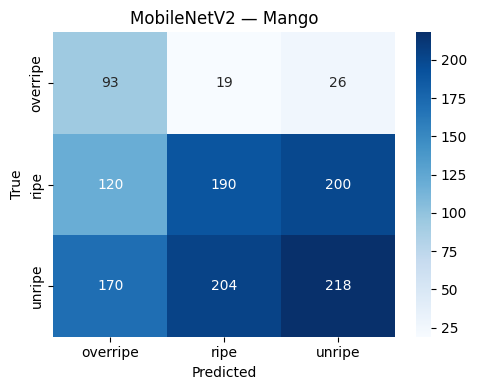

Found 664 images belonging to 3 classes.

  MobileNetV2  |  Tomato
  Accuracy : 0.5858
  Loss     : 2.6360

Classification Report:
              precision    recall  f1-score   support

    overripe       0.46      0.29      0.36        78
        ripe       0.64      0.36      0.46       289
      unripe       0.58      0.88      0.70       297

    accuracy                           0.59       664
   macro avg       0.56      0.51      0.51       664
weighted avg       0.59      0.59      0.56       664



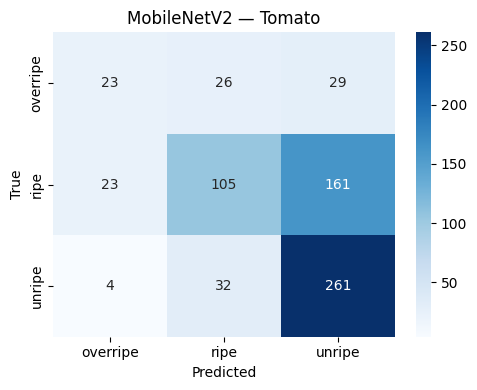

Found 771 images belonging to 3 classes.

  EfficientNetB0  |  Apple
  Accuracy : 0.5240
  Loss     : 2.8264

Classification Report:
              precision    recall  f1-score   support

    overripe       0.54      0.46      0.50       133
        ripe       0.54      0.47      0.50       319
      unripe       0.50      0.61      0.55       319

    accuracy                           0.52       771
   macro avg       0.53      0.51      0.52       771
weighted avg       0.53      0.52      0.52       771



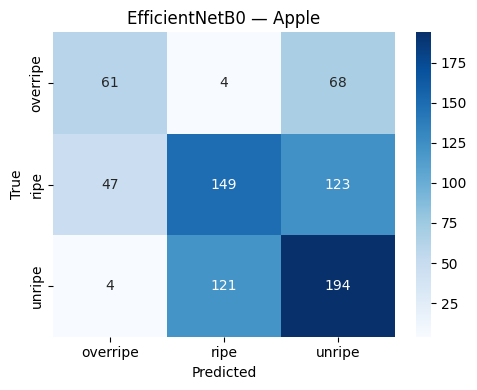

Found 1090 images belonging to 3 classes.

  EfficientNetB0  |  Banana
  Accuracy : 0.5817
  Loss     : 2.9244

Classification Report:
              precision    recall  f1-score   support

    overripe       0.97      0.65      0.78       341
        ripe       0.40      0.96      0.56       291
      unripe       0.85      0.29      0.43       458

    accuracy                           0.58      1090
   macro avg       0.74      0.63      0.59      1090
weighted avg       0.77      0.58      0.57      1090



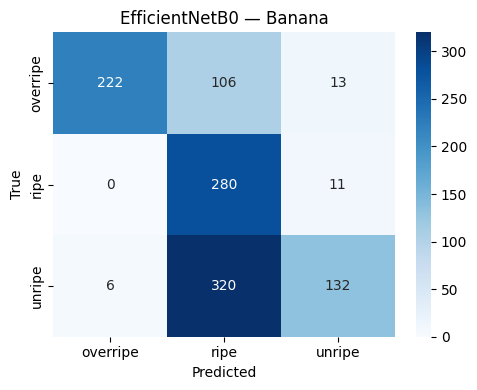

Found 328 images belonging to 3 classes.

  EfficientNetB0  |  Orange
  Accuracy : 0.6982
  Loss     : 2.2318

Classification Report:
              precision    recall  f1-score   support

    overripe       0.91      0.59      0.72        86
        ripe       0.60      0.66      0.63       113
      unripe       0.70      0.80      0.74       129

    accuracy                           0.70       328
   macro avg       0.74      0.69      0.70       328
weighted avg       0.72      0.70      0.70       328



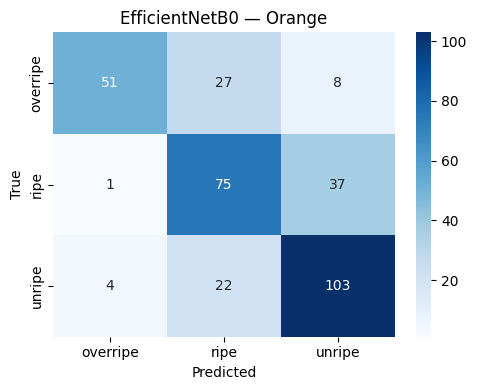

Found 1240 images belonging to 3 classes.

  EfficientNetB0  |  Mango
  Accuracy : 0.4427
  Loss     : 1.9023

Classification Report:
              precision    recall  f1-score   support

    overripe       0.22      0.37      0.27       138
        ripe       0.48      0.60      0.53       510
      unripe       0.52      0.32      0.40       592

    accuracy                           0.44      1240
   macro avg       0.41      0.43      0.40      1240
weighted avg       0.47      0.44      0.44      1240



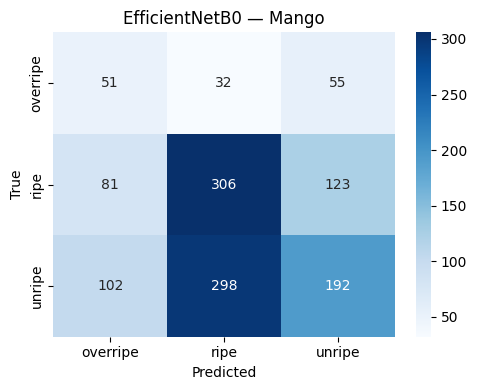

Found 664 images belonging to 3 classes.

  EfficientNetB0  |  Tomato
  Accuracy : 0.5843
  Loss     : 3.3946

Classification Report:
              precision    recall  f1-score   support

    overripe       0.67      0.21      0.31        78
        ripe       0.62      0.44      0.52       289
      unripe       0.56      0.82      0.67       297

    accuracy                           0.58       664
   macro avg       0.62      0.49      0.50       664
weighted avg       0.60      0.58      0.56       664



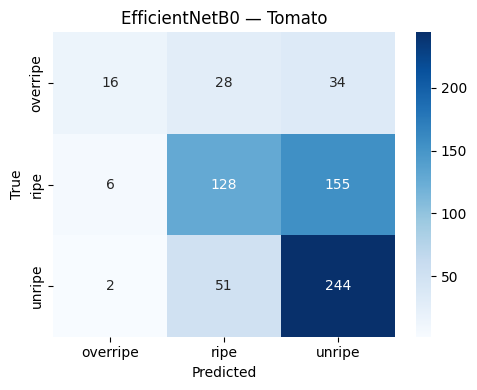

Found 771 images belonging to 3 classes.

  ResNet50  |  Apple
  Accuracy : 0.5486
  Loss     : 2.9436

Classification Report:
              precision    recall  f1-score   support

    overripe       0.53      0.71      0.61       133
        ripe       0.52      0.35      0.42       319
      unripe       0.57      0.68      0.62       319

    accuracy                           0.55       771
   macro avg       0.54      0.58      0.55       771
weighted avg       0.54      0.55      0.53       771



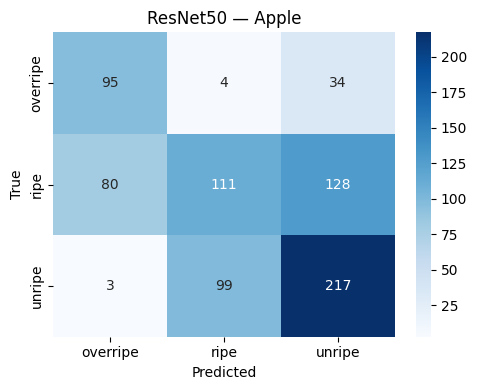

Found 1090 images belonging to 3 classes.

  ResNet50  |  Banana
  Accuracy : 0.6376
  Loss     : 1.9339

Classification Report:
              precision    recall  f1-score   support

    overripe       0.60      0.89      0.72       341
        ripe       0.59      0.79      0.68       291
      unripe       0.81      0.35      0.49       458

    accuracy                           0.64      1090
   macro avg       0.67      0.68      0.63      1090
weighted avg       0.69      0.64      0.61      1090



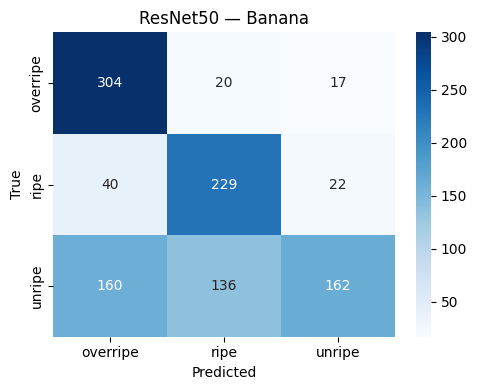

Found 328 images belonging to 3 classes.

  ResNet50  |  Orange
  Accuracy : 0.6738
  Loss     : 1.9391

Classification Report:
              precision    recall  f1-score   support

    overripe       0.98      0.60      0.75        86
        ripe       0.62      0.47      0.54       113
      unripe       0.61      0.90      0.73       129

    accuracy                           0.67       328
   macro avg       0.74      0.66      0.67       328
weighted avg       0.71      0.67      0.67       328



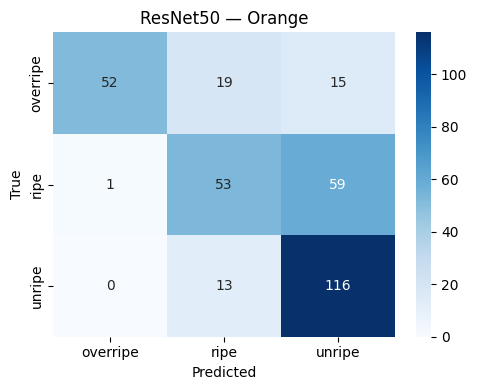

Found 1240 images belonging to 3 classes.

  ResNet50  |  Mango
  Accuracy : 0.3427
  Loss     : 2.7645

Classification Report:
              precision    recall  f1-score   support

    overripe       0.19      0.63      0.30       138
        ripe       0.45      0.45      0.45       510
      unripe       0.38      0.19      0.25       592

    accuracy                           0.34      1240
   macro avg       0.34      0.42      0.33      1240
weighted avg       0.39      0.34      0.34      1240



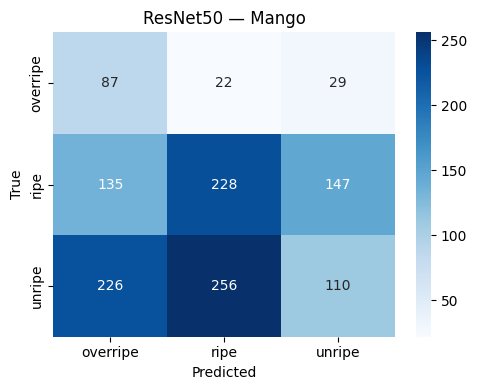

Found 664 images belonging to 3 classes.

  ResNet50  |  Tomato
  Accuracy : 0.5678
  Loss     : 2.8759

Classification Report:
              precision    recall  f1-score   support

    overripe       0.56      0.23      0.33        78
        ripe       0.63      0.44      0.52       289
      unripe       0.54      0.78      0.64       297

    accuracy                           0.57       664
   macro avg       0.58      0.48      0.49       664
weighted avg       0.58      0.57      0.55       664



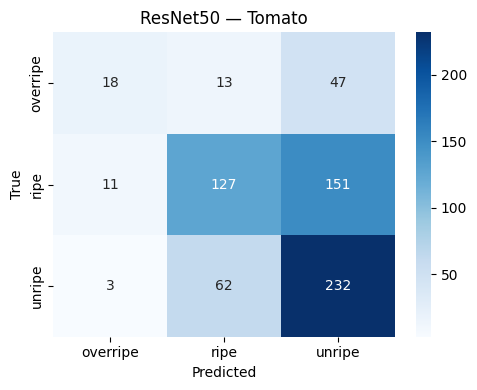

In [8]:
all_results = {}   # all_results[model_name][fruit_name] = accuracy
all_preds   = {}   # all_preds[model_name][fruit_name]   = raw softmax predictions
all_true    = {}   # true labels per fruit (same across models)

for model_name, cfg in MODEL_CONFIG.items():

    all_results[model_name] = {}
    all_preds[model_name]   = {}

    for fruit_name, fruit_path in fruit_paths.items():

        acc, preds, y_true, _ = evaluate_fruit(
            model     = cfg["model"],
            preprocess_fn = cfg["preprocess"],
            fruit_path    = fruit_path,
            fruit_name    = fruit_name,
            model_name    = model_name,
            save_cm       = True
        )

        all_results[model_name][fruit_name] = acc
        all_preds[model_name][fruit_name]   = preds
        all_true[fruit_name]                = y_true


# Ensemble Evaluation — Per Fruit

Apply the same weighted ensemble used during training. Because each model was preprocessed differently, we combine their raw softmax outputs (which are probability distributions and therefore comparable) using the accuracy-derived weights.

In [9]:
print("\nEnsemble Results (Weighted Average)")
print("="*55)

all_results["Ensemble"] = {}

for fruit_name in fruit_paths:

    p1 = all_preds["MobileNetV2"][fruit_name]
    p2 = all_preds["EfficientNetB0"][fruit_name]
    p3 = all_preds["ResNet50"][fruit_name]

    ensemble_pred    = (w1 * p1) + (w2 * p2) + (w3 * p3)
    ensemble_classes = np.argmax(ensemble_pred, axis=1)
    y_true           = all_true[fruit_name]

    acc = np.mean(ensemble_classes == y_true)
    all_results["Ensemble"][fruit_name] = acc

    print(f"  {fruit_name}: {acc:.4f}")



Ensemble Results (Weighted Average)
  Apple: 0.5863
  Banana: 0.6596
  Orange: 0.7378
  Mango: 0.4113
  Tomato: 0.5934


# Final Accuracy Summary Table

In [10]:
print("\n" + "="*70)
print("FINAL ACCURACY SUMMARY")
print("="*70)

model_names = list(all_results.keys())
fruit_names = list(fruit_paths.keys())

summary_df = pd.DataFrame(all_results).T
summary_df.index.name = "Model"

print(summary_df.round(4).to_string())



FINAL ACCURACY SUMMARY
                 Apple  Banana  Orange   Mango  Tomato
Model                                                 
MobileNetV2     0.5551  0.6917  0.7073  0.4040  0.5858
EfficientNetB0  0.5240  0.5817  0.6982  0.4427  0.5843
ResNet50        0.5486  0.6376  0.6738  0.3427  0.5678
Ensemble        0.5863  0.6596  0.7378  0.4113  0.5934


# Visualisation — Per-Fruit Accuracy Grouped Bar Chart

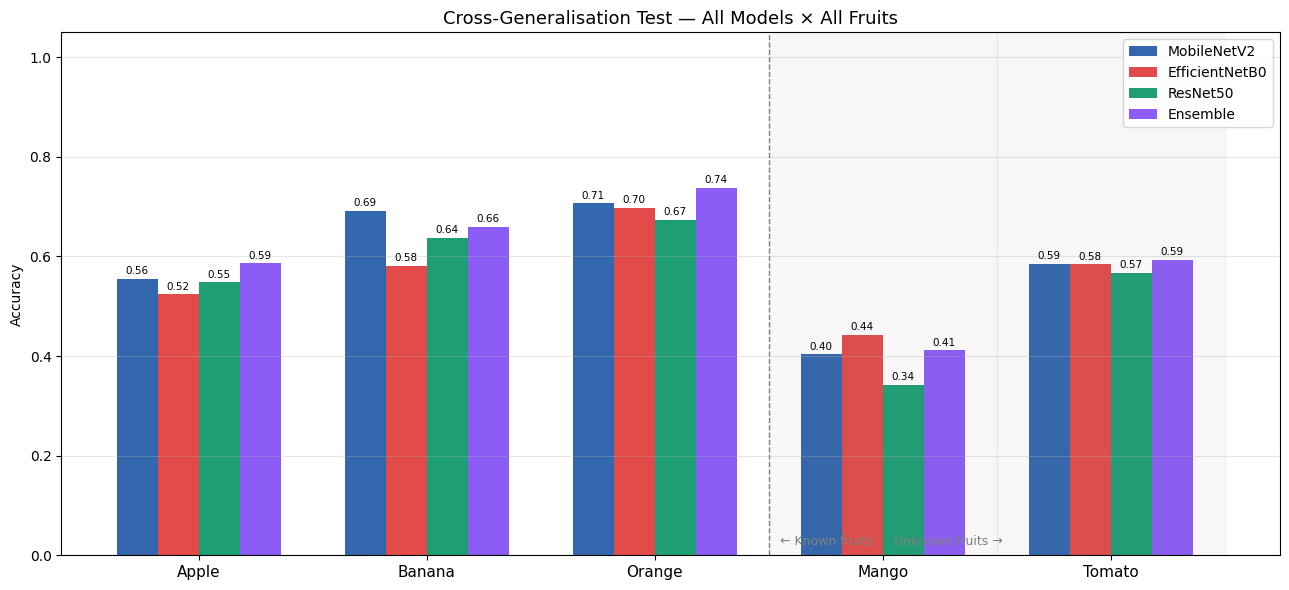

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))

x          = np.arange(len(fruit_names))
n_models   = len(model_names)
bar_width  = 0.18
colors     = ["#3266ad", "#E24B4A", "#1D9E75", "#8B5CF6"]

for i, (mname, color) in enumerate(zip(model_names, colors)):
    offsets = x + (i - n_models / 2 + 0.5) * bar_width
    accs    = [all_results[mname][f] for f in fruit_names]
    bars    = ax.bar(offsets, accs, bar_width, label=mname, color=color)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{acc:.2f}", ha='center', va='bottom', fontsize=7.5)

# Shade unknown fruits
for xi in range(len(KNOWN_FRUITS), len(fruit_names)):
    ax.axvspan(xi - 0.5, xi + 0.5, alpha=0.06, color='gray')

ax.axvline(x=len(KNOWN_FRUITS) - 0.5, color='gray', linestyle='--', linewidth=1)
ax.text(len(KNOWN_FRUITS) - 0.45, 0.02, '← Known fruits', fontsize=9, color='gray')
ax.text(len(KNOWN_FRUITS) + 0.05, 0.02, 'Unknown fruits →', fontsize=9, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(fruit_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Cross-Generalisation Test — All Models × All Fruits", fontsize=13)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("cross_generalisation_results.png", dpi=150)
plt.show()


# Known vs Unknown Fruit Analysis

This section quantifies how much accuracy drops on fruits the model never saw during training — the key metric for transfer learning quality.

In [12]:
print("\nKNOWN vs UNKNOWN FRUIT ACCURACY")
print("="*55)

for mname in model_names:
    known_acc   = np.mean([all_results[mname][f] for f in KNOWN_FRUITS])
    unknown_acc = np.mean([all_results[mname][f] for f in UNKNOWN_FRUITS])
    drop        = known_acc - unknown_acc

    print(f"\n{mname}")
    print(f"  Known fruits   : {known_acc:.4f}")
    print(f"  Unknown fruits : {unknown_acc:.4f}")
    print(f"  Generalisation drop: {drop:.4f} ({drop*100:.1f} pp)")



KNOWN vs UNKNOWN FRUIT ACCURACY

MobileNetV2
  Known fruits   : 0.6514
  Unknown fruits : 0.4949
  Generalisation drop: 0.1565 (15.6 pp)

EfficientNetB0
  Known fruits   : 0.6013
  Unknown fruits : 0.5135
  Generalisation drop: 0.0877 (8.8 pp)

ResNet50
  Known fruits   : 0.6200
  Unknown fruits : 0.4553
  Generalisation drop: 0.1648 (16.5 pp)

Ensemble
  Known fruits   : 0.6612
  Unknown fruits : 0.5023
  Generalisation drop: 0.1589 (15.9 pp)


# Save Summary CSV

In [13]:
summary_df.to_csv("cross_generalisation_results.csv")
print("Results saved to cross_generalisation_results.csv")


Results saved to cross_generalisation_results.csv
